# PPath Planning mediante Wavefront

Este notebook explicar desde cero cómo realizar **Path Planning** sobre una cuadrícula utilizando un método de **Wavefront ponderado**.

El objetivo será encontrar una ruta libre de colisiones entre una posición inicial y una meta dentro de un mapa discreto.

El flujo general será:

$$
\text{Mapa}
\rightarrow
\text{Meta}
\rightarrow
\text{Propagación de costos}
\rightarrow
\text{Campo de costos}
\rightarrow
\text{Descenso de costos}
\rightarrow
\text{Trayectoria}
$$

Además de implementar el algoritmo, se visualizarán por separado el mapa inicial, las celdas ocupadas, el campo de costos y la trayectoria final.


## 1. ¿Qué es Path Planning?

La planificación de trayectorias consiste en determinar una secuencia de posiciones que permita llevar un robot desde un punto inicial hasta una meta evitando obstáculos.

En un mapa discretizado, cada celda puede interpretarse como un estado posible del robot. Para resolver el problema se necesita definir:

- un mapa
- una posición inicial
- una posición meta
- los movimientos permitidos
- una función de costo

El resultado será una secuencia de celdas que conecte inicio y meta sin atravesar obstáculos.


## 2. ¿Qué es Wavefront?

Wavefront, o propagación de frente de onda, comenzar en la meta y expandir valores hacia las celdas vecinas.

La meta se inicializa con:

$$
J(\text{meta})=0
$$

Para cada vecino se calcular:

$$
J(n)=J(c)+C(c,n)
$$

donde:

- ($J(c)$) es el costo acumulado de la celda actual;
- \(C(c,n)\) es el costo del movimiento;
- \(J(n)\) es el costo candidato del vecino.

Cuando la propagación termina, cada celda libre contiene el costo mínimo requerido para llegar hasta la meta.


## 3. Wavefront ponderado

En este ejercicio el robot puede desplazarse en ocho direcciones.

Los movimientos horizontales y verticales tendrán costo:

$$
C=1
$$

Los movimientos diagonales tendrán costo aproximado:

$$
C\approx\sqrt{2}\approx1.4
$$

Por ello no se trata de una propagación uniforme. Se utiliza una cola de prioridad para expandir siempre primero la celda con menor costo acumulado. Esta implementación puede interpretarse como un **Wavefront ponderado**, y computacionalmente corresponde a una propagación tipo Dijkstra desde la meta.


## 4. Librerías

Importar las bibliotecas necesarias para manejar la cola de prioridad, matrices y visualizaciones.


In [21]:
import heapq
import numpy as np
import matplotlib.pyplot as plt


## 5. Definición del mapa

Representar el entorno mediante una matriz binaria:

- `0`: espacio libre.
- `1`: obstáculo.

Las posiciones utilizarán el formato `(fila, columna)`.


In [22]:
mapa = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
], dtype=int)

inicio = (7, 8)
meta = (7, 2)

print('Tamaño del mapa:', mapa.shape)
print('Inicio:', inicio)
print('Meta:', meta)


Tamaño del mapa: (10, 10)
Inicio: (7, 8)
Meta: (7, 2)


## 6. Visualizar el mapa inicial

Antes de calcular cualquier ruta conviene observar el entorno original. En esta etapa todavía no existe campo de costos ni trayectoria.


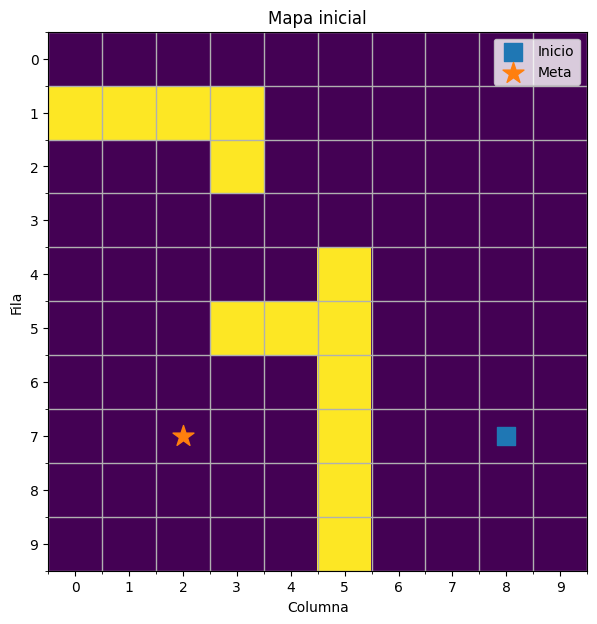

In [23]:
figura, eje = plt.subplots(figsize=(7, 7))

eje.imshow(mapa, origin='upper')

eje.scatter(inicio[1], inicio[0], marker='s', s=180, label='Inicio')
eje.scatter(meta[1], meta[0], marker='*', s=250, label='Meta')

eje.set_xticks(np.arange(mapa.shape[1]))
eje.set_yticks(np.arange(mapa.shape[0]))
eje.set_xticks(np.arange(-0.5, mapa.shape[1], 1), minor=True)
eje.set_yticks(np.arange(-0.5, mapa.shape[0], 1), minor=True)
eje.grid(which='minor', linewidth=1)

eje.set_title('Mapa inicial')
eje.set_xlabel('Columna')
eje.set_ylabel('Fila')
eje.legend()

plt.show()


## 7. Identificar las celdas ocupadas

Extraer las coordenadas de todos los obstáculos permite comprobar que el mapa contiene exactamente las celdas esperadas.


In [24]:
celdas_ocupadas = np.argwhere(mapa == 1)

print('Número de celdas ocupadas:', len(celdas_ocupadas))
print('Coordenadas ocupadas:')

for fila, columna in celdas_ocupadas:
    print((fila, columna))


Número de celdas ocupadas: 13
Coordenadas ocupadas:
(np.int64(1), np.int64(0))
(np.int64(1), np.int64(1))
(np.int64(1), np.int64(2))
(np.int64(1), np.int64(3))
(np.int64(2), np.int64(3))
(np.int64(4), np.int64(5))
(np.int64(5), np.int64(3))
(np.int64(5), np.int64(4))
(np.int64(5), np.int64(5))
(np.int64(6), np.int64(5))
(np.int64(7), np.int64(5))
(np.int64(8), np.int64(5))
(np.int64(9), np.int64(5))


## 8. Modelo de movimiento

Permitir ocho movimientos, similares a los de un rey en ajedrez.

Cada movimiento se almacenar como:

```text
(desplazamiento_fila, desplazamiento_columna, costo)
```

Los movimientos rectos cuestan \(1\), mientras que las diagonales cuestan \(1.4\).


In [25]:
movimientos = [
    (-1,  0, 1.0),   # arriba
    ( 1,  0, 1.0),   # abajo
    ( 0, -1, 1.0),   # izquierda
    ( 0,  1, 1.0),   # derecha

    (-1, -1, 1.4),   # diagonal superior izquierda
    (-1,  1, 1.4),   # diagonal superior derecha
    ( 1, -1, 1.4),   # diagonal inferior izquierda
    ( 1,  1, 1.4)    # diagonal inferior derecha
]

for movimiento in movimientos:
    print(movimiento)


(-1, 0, 1.0)
(1, 0, 1.0)
(0, -1, 1.0)
(0, 1, 1.0)
(-1, -1, 1.4)
(-1, 1, 1.4)
(1, -1, 1.4)
(1, 1, 1.4)


## 9. ¿Por qué la diagonal cuesta 1.4?

Si cada celda mide una unidad, un movimiento horizontal o vertical recorre:

\[
d=1
\]

Una diagonal recorre:

\[
d=\sqrt{1^2+1^2}=\sqrt{2}\approx1.414
\]

En el código se utilizar \(1.4\) como aproximación.


In [26]:
print('Distancia diagonal exacta:', np.sqrt(2))
print('Valor aproximado utilizado:', 1.4)


Distancia diagonal exacta: 1.4142135623730951
Valor aproximado utilizado: 1.4


## 10. Verificar posiciones válidas

Antes de aceptar una celda se deben verificar dos condiciones:

1. que se encuentre dentro de los límites del mapa;
2. que no corresponda a un obstáculo.


In [27]:
def posicion_valida(mapa, fila, columna):
    """Verificar límites del mapa y ausencia de obstáculo."""

    filas, columnas = mapa.shape

    dentro_del_mapa = (
        0 <= fila < filas and
        0 <= columna < columnas
    )

    if not dentro_del_mapa:
        return False

    if mapa[fila, columna] == 1:
        return False

    return True


## 11. Probar la función de posición válida

Probar algunas celdas permite comprobar la función antes de utilizarla dentro del algoritmo principal.


In [28]:
pruebas = [
    (0, 0),
    (1, 0),
    (7, 8),
    (-1, 0),
    (10, 10)
]

for fila, columna in pruebas:
    print(
        (fila, columna),
        '->',
        posicion_valida(mapa, fila, columna)
    )


(0, 0) -> True
(1, 0) -> False
(7, 8) -> True
(-1, 0) -> False
(10, 10) -> False


## 12. Evitar cortar esquinas

Permitir diagonales puede generar rutas geométricamente inválidas. El robot podría intentar atravesar una esquina ocupada.

Para un movimiento diagonal \((\Delta f,\Delta c)\), revisar también las celdas:

\[
(f+\Delta f,c)
\]

y

\[
(f,c+\Delta c)
\]

La diagonal sólo se permitirá si ambas están libres.


In [29]:
def diagonal_permitida(mapa, actual, movimiento):
    """Evitar que el robot atraviese diagonalmente una esquina."""

    fila, columna = actual
    df, dc, _ = movimiento

    if df == 0 or dc == 0:
        return True

    celda_vertical = (fila + df, columna)
    celda_horizontal = (fila, columna + dc)

    vertical_libre = posicion_valida(
        mapa,
        celda_vertical[0],
        celda_vertical[1]
    )

    horizontal_libre = posicion_valida(
        mapa,
        celda_horizontal[0],
        celda_horizontal[1]
    )

    return vertical_libre and horizontal_libre


## 13. Inicializar el mapa de costos

Crear una matriz del mismo tamaño que el mapa y asignar inicialmente infinito a todas las celdas:

\[
J(i,j)=\infty
\]

Esto indicar que todavía no se conoce una ruta hacia la meta.

Sólo la meta iniciar con:

\[
J(\text{meta})=0
\]


In [30]:
costos_iniciales = np.full(
    shape=mapa.shape,
    fill_value=np.inf,
    dtype=float
)

costos_iniciales[meta] = 0.0

print(costos_iniciales)


[[inf inf inf inf inf inf inf inf inf inf]
 [inf inf inf inf inf inf inf inf inf inf]
 [inf inf inf inf inf inf inf inf inf inf]
 [inf inf inf inf inf inf inf inf inf inf]
 [inf inf inf inf inf inf inf inf inf inf]
 [inf inf inf inf inf inf inf inf inf inf]
 [inf inf inf inf inf inf inf inf inf inf]
 [inf inf  0. inf inf inf inf inf inf inf]
 [inf inf inf inf inf inf inf inf inf inf]
 [inf inf inf inf inf inf inf inf inf inf]]


## 14. Cola de prioridad

Como los movimientos tienen costos diferentes, no conviene procesar las celdas únicamente en orden de llegada.

`heapq` permite extraer siempre la entrada con menor costo acumulado. Así, si existen costos 1.4, 2.0 y 3.0, se procesará primero 1.4.

Esta es la razón técnica por la cual la implementación se comporta como una propagación ponderada tipo Dijkstra.


## 15. Propagación del campo de costos

Para cada celda extraída de la cola, evaluar todos sus vecinos.

Calcular:

\[
J_{nuevo}=J_{actual}+C_{movimiento}
\]

Si:

\[
J_{nuevo}<J_{almacenado}
\]

actualizar el costo y volver a insertar la celda en la cola de prioridad.


In [31]:
def calcular_mapa_costos(mapa, meta):
    """Calcular el costo mínimo desde cada celda libre hasta la meta."""

    filas, columnas = mapa.shape

    costos = np.full(
        shape=(filas, columnas),
        fill_value=np.inf,
        dtype=float
    )

    costos[meta] = 0.0

    cola = [(0.0, meta[0], meta[1])]

    while cola:

        costo_actual, fila, columna = heapq.heappop(cola)

        if costo_actual > costos[fila, columna]:
            continue

        actual = (fila, columna)

        for movimiento in movimientos:

            df, dc, costo_movimiento = movimiento

            nueva_fila = fila + df
            nueva_columna = columna + dc

            if not posicion_valida(mapa, nueva_fila, nueva_columna):
                continue

            if not diagonal_permitida(mapa, actual, movimiento):
                continue

            nuevo_costo = costo_actual + costo_movimiento

            if nuevo_costo < costos[nueva_fila, nueva_columna]:

                costos[nueva_fila, nueva_columna] = nuevo_costo

                heapq.heappush(
                    cola,
                    (nuevo_costo, nueva_fila, nueva_columna)
                )

    return costos


## 16. Ejecutar Wavefront ponderado

Calcular el campo completo de costos. Cada número indicar el costo mínimo necesario para llegar desde esa celda hasta la meta.


In [32]:
costos = calcular_mapa_costos(
    mapa=mapa,
    meta=meta
)

print(costos)


[[12.4 11.4 10.4  9.4  8.4  8.8  9.2  9.6 10.6 11.6]
 [ inf  inf  inf  inf  7.4  7.8  8.2  9.2 10.2 11.2]
 [ 5.8  5.4  5.   inf  6.4  6.8  7.8  8.8  9.8 10.8]
 [ 4.8  4.4  4.   4.4  5.4  6.4  7.4  8.4  9.4 10.4]
 [ 3.8  3.4  3.   4.   5.   inf  8.4  8.8  9.8 10.8]
 [ 2.8  2.4  2.   inf  inf  inf  9.4  9.8 10.2 11.2]
 [ 2.4  1.4  1.   1.4  2.4  inf 10.4 10.8 11.2 11.6]
 [ 2.   1.   0.   1.   2.   inf 11.4 11.8 12.2 12.6]
 [ 2.4  1.4  1.   1.4  2.4  inf 12.4 12.8 13.2 13.6]
 [ 2.8  2.4  2.   2.4  2.8  inf 13.4 13.8 14.2 14.6]]


## 17. Visualizar el campo de costos

Mostrar los valores propagados antes de dibujar la trayectoria.

- `X`: obstáculo.
- `∞`: celda inaccesible.
- número: costo mínimo hasta la meta.


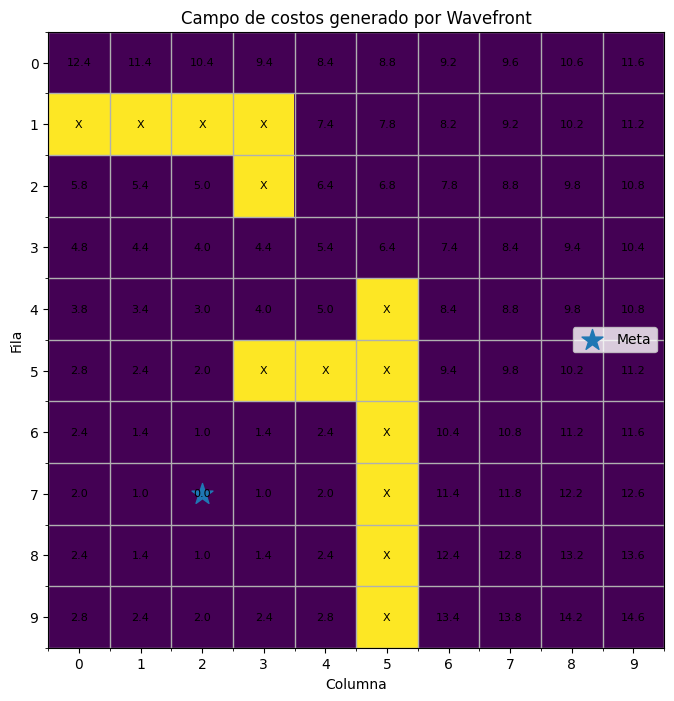

In [33]:
figura, eje = plt.subplots(figsize=(8, 8))

eje.imshow(mapa, origin='upper')

for fila in range(mapa.shape[0]):
    for columna in range(mapa.shape[1]):

        if mapa[fila, columna] == 1:
            texto = 'X'
        elif np.isinf(costos[fila, columna]):
            texto = '∞'
        else:
            texto = f'{costos[fila, columna]:.1f}'

        eje.text(
            columna,
            fila,
            texto,
            ha='center',
            va='center',
            fontsize=8
        )

eje.scatter(meta[1], meta[0], marker='*', s=250, label='Meta')

eje.set_xticks(np.arange(mapa.shape[1]))
eje.set_yticks(np.arange(mapa.shape[0]))
eje.set_xticks(np.arange(-0.5, mapa.shape[1], 1), minor=True)
eje.set_yticks(np.arange(-0.5, mapa.shape[0], 1), minor=True)
eje.grid(which='minor', linewidth=1)

eje.set_title('Campo de costos generado por Wavefront')
eje.set_xlabel('Columna')
eje.set_ylabel('Fila')
eje.legend()

plt.show()


## 18. Interpretación del campo de costos

La meta representar el punto de menor costo:

\[
J=0
\]

A medida que una celda se aleja o debe rodear obstáculos, el costo aumentar.

Por ello la trayectoria puede extraerse siguiendo vecinos que satisfagan:

\[
J_{k+1}<J_k
\]

hasta llegar a la meta.


## 19. Extraer la trayectoria

Comenzar en `inicio` y elegir sucesivamente el vecino válido con menor costo.

El proceso termina cuando la celda actual coincide con la meta.


In [34]:
def extraer_trayectoria(mapa, costos, inicio, meta):
    """Obtener la trayectoria siguiendo valores descendentes del campo."""

    trayectoria = [inicio]
    actual = inicio

    while actual != meta:

        fila, columna = actual

        mejor_vecino = None
        mejor_costo = costos[fila, columna]

        for movimiento in movimientos:

            df, dc, _ = movimiento

            nueva_fila = fila + df
            nueva_columna = columna + dc

            if not posicion_valida(mapa, nueva_fila, nueva_columna):
                continue

            if not diagonal_permitida(mapa, actual, movimiento):
                continue

            costo_vecino = costos[nueva_fila, nueva_columna]

            if costo_vecino < mejor_costo:
                mejor_costo = costo_vecino
                mejor_vecino = (nueva_fila, nueva_columna)

        if mejor_vecino is None:
            raise RuntimeError(
                'No se encontró una trayectoria válida hacia la meta.'
            )

        actual = mejor_vecino
        trayectoria.append(actual)

    return trayectoria


## 20. Calcular la trayectoria

Aplicar el descenso sobre el campo de costos generado anteriormente.


In [35]:
trayectoria = extraer_trayectoria(
    mapa=mapa,
    costos=costos,
    inicio=inicio,
    meta=meta
)

print('Trayectoria encontrada:')

for paso, posicion in enumerate(trayectoria):
    print(f'Paso {paso}: {posicion}')


Trayectoria encontrada:
Paso 0: (7, 8)
Paso 1: (6, 7)
Paso 2: (5, 6)
Paso 3: (4, 6)
Paso 4: (3, 6)
Paso 5: (3, 5)
Paso 6: (3, 4)
Paso 7: (4, 3)
Paso 8: (4, 2)
Paso 9: (5, 2)
Paso 10: (6, 2)
Paso 11: (7, 2)


## 21. Número de movimientos y costo total

El número de movimientos y el costo total no son necesariamente iguales, porque las diagonales cuestan 1.4.


In [36]:
numero_movimientos = len(trayectoria) - 1
costo_total = costos[inicio]

print('Número de movimientos:', numero_movimientos)
print('Costo total:', round(costo_total, 2))


Número de movimientos: 11
Costo total: 12.2


## 22. Verificación manual del costo

Contar movimientos rectos y diagonales permite comprobar que la trayectoria coincide con el costo almacenado en el campo Wavefront.


In [37]:
movimientos_rectos = 0
movimientos_diagonales = 0

for i in range(len(trayectoria) - 1):

    fila_1, columna_1 = trayectoria[i]
    fila_2, columna_2 = trayectoria[i + 1]

    df = abs(fila_2 - fila_1)
    dc = abs(columna_2 - columna_1)

    if df == 1 and dc == 1:
        movimientos_diagonales += 1
    else:
        movimientos_rectos += 1

costo_manual = (
    movimientos_rectos * 1.0
    + movimientos_diagonales * 1.4
)

print('Movimientos rectos:', movimientos_rectos)
print('Movimientos diagonales:', movimientos_diagonales)
print('Costo manual:', round(costo_manual, 2))
print('Costo Wavefront:', round(costos[inicio], 2))


Movimientos rectos: 8
Movimientos diagonales: 3
Costo manual: 12.2
Costo Wavefront: 12.2


## 23. Visualizar solamente la trayectoria

Mostrar la ruta sobre el mapa sin los valores numéricos facilita evaluar visualmente la geometría de la solución.


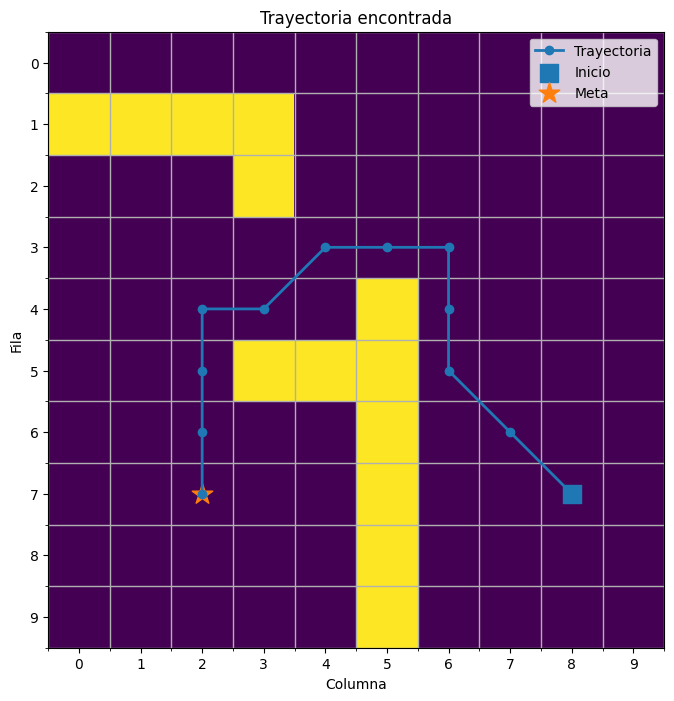

In [38]:
figura, eje = plt.subplots(figsize=(8, 8))

eje.imshow(mapa, origin='upper')

filas_trayectoria = [p[0] for p in trayectoria]
columnas_trayectoria = [p[1] for p in trayectoria]

eje.plot(
    columnas_trayectoria,
    filas_trayectoria,
    marker='o',
    linewidth=2,
    label='Trayectoria'
)

eje.scatter(inicio[1], inicio[0], marker='s', s=170, label='Inicio')
eje.scatter(meta[1], meta[0], marker='*', s=240, label='Meta')

eje.set_xticks(np.arange(mapa.shape[1]))
eje.set_yticks(np.arange(mapa.shape[0]))
eje.set_xticks(np.arange(-0.5, mapa.shape[1], 1), minor=True)
eje.set_yticks(np.arange(-0.5, mapa.shape[0], 1), minor=True)
eje.grid(which='minor', linewidth=1)

eje.set_title('Trayectoria encontrada')
eje.set_xlabel('Columna')
eje.set_ylabel('Fila')
eje.legend()

plt.show()


## 24. Visualización final

Combinar mapa, obstáculos, costos, inicio, meta y trayectoria en una sola figura.


In [39]:
def mostrar_resultado(mapa, costos, trayectoria, inicio, meta):
    """Mostrar el resultado completo del planificador."""

    figura, eje = plt.subplots(figsize=(8, 8))

    eje.imshow(mapa, origin='upper')

    for fila in range(mapa.shape[0]):
        for columna in range(mapa.shape[1]):

            if mapa[fila, columna] == 1:
                texto = 'X'
            elif np.isinf(costos[fila, columna]):
                texto = '∞'
            else:
                texto = f'{costos[fila, columna]:.1f}'

            eje.text(
                columna,
                fila,
                texto,
                ha='center',
                va='center',
                fontsize=8
            )

    filas_trayectoria = [p[0] for p in trayectoria]
    columnas_trayectoria = [p[1] for p in trayectoria]

    eje.plot(
        columnas_trayectoria,
        filas_trayectoria,
        marker='o',
        linewidth=2,
        label='Trayectoria'
    )

    eje.scatter(inicio[1], inicio[0], marker='s', s=160, label='Inicio R')
    eje.scatter(meta[1], meta[0], marker='*', s=220, label='Meta R')

    eje.set_xticks(np.arange(mapa.shape[1]))
    eje.set_yticks(np.arange(mapa.shape[0]))
    eje.set_xticks(np.arange(-0.5, mapa.shape[1], 1), minor=True)
    eje.set_yticks(np.arange(-0.5, mapa.shape[0], 1), minor=True)
    eje.grid(which='minor', linewidth=1)

    eje.set_title('Planificación de trayectoria mediante Wavefront ponderado')
    eje.set_xlabel('Columna')
    eje.set_ylabel('Fila')
    eje.legend()

    plt.show()


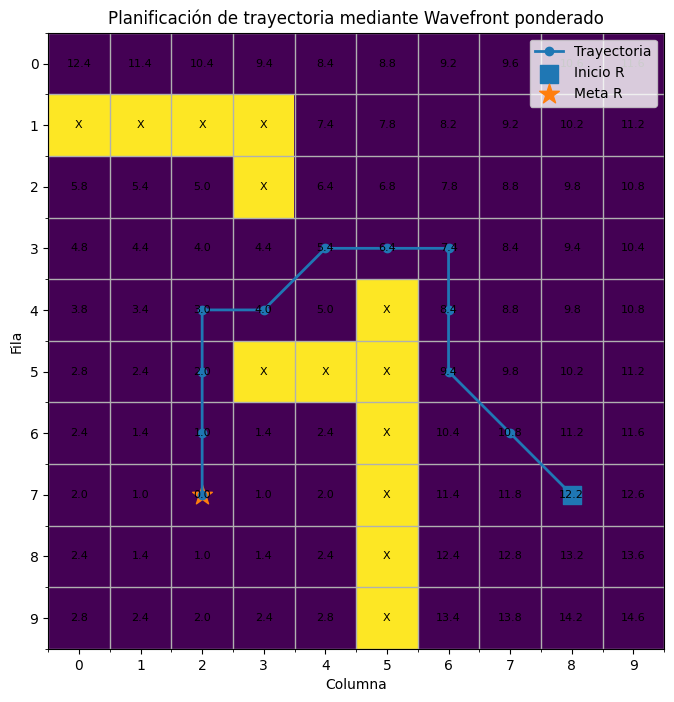

In [40]:
mostrar_resultado(
    mapa=mapa,
    costos=costos,
    trayectoria=trayectoria,
    inicio=inicio,
    meta=meta
)


## 25. Ejemplo conceptual de propagación

Supongamos una meta en la esquina inferior derecha:

```text
? ? ?
? ? ?
? ? G
```

Inicialmente:

```text
?   ?   ?
?   ?   ?
?   ?  0.0
```

Después de la primera expansión:

```text
?    ?    ?
?   1.4  1.0
?   1.0  0.0
```

La propagación continúa siempre desde el menor costo disponible. Los obstáculos bloquean el avance y obligan al frente de onda a rodearlos.


## 26. Relación con Dijkstra

La implementación utiliza una cola de prioridad porque los movimientos tienen costos diferentes.

Por ello, aunque conceptualmente se explicar como Wavefront ponderado, el procedimiento computacional corresponde a ejecutar **Dijkstra desde la meta sobre una cuadrícula de ocho vecinos**.

La diferencia conceptual importante es que aquí Dijkstra se utiliza para construir un **campo de costos completo** hacia una meta, y posteriormente la ruta se extrae mediante descenso de costos.


## 27. ¿Por qué comenzar desde la meta?

Al propagar desde la meta se generar un campo:

\[
J(i,j)
\]

que puede reutilizarse para cualquier posición inicial que se encuentre en el mismo mapa.

Así, varias posiciones iniciales pueden dirigirse hacia la misma meta sin recalcular completamente el campo.


## 28. Limitación física: el robot se considera un punto

El algoritmo actual comprobar únicamente si la celda destino está ocupada. Esto equivale a considerar que el robot ocupa una sola celda.

En un robot real se deberá considerar su ancho y longitud. Una estrategia común consiste en **inflar los obstáculos** antes de planificar, expandiéndolos de acuerdo con el radio efectivo del robot más un margen de seguridad.


## 29. Relación con un Occupancy Grid

Este ejemplo utiliza un mapa creado manualmente, pero la misma lógica puede aplicarse a un mapa generado por sensores.

El flujo completo sería:

```text
16 sensores
    ↓
mapa local
    ↓
transformación global
    ↓
Occupancy Grid
    ↓
inflado de obstáculos
    ↓
Wavefront ponderado
    ↓
trayectoria
    ↓
control del robot
```

De esta forma, el algoritmo puede integrarse posteriormente con el mapa global construido en CoppeliaSim.


## 30. Flujo completo del algoritmo

El procedimiento realizado puede resumirse así:

1. Definir el mapa.
2. Definir inicio y meta.
3. Definir movimientos y costos.
4. Validar límites y obstáculos.
5. Evitar diagonales inseguras.
6. Inicializar el campo de costos en infinito.
7. Asignar cero a la meta.
8. Propagar costos mediante cola de prioridad.
9. Obtener el campo completo.
10. Comenzar desde el inicio.
11. Elegir vecinos de menor costo.
12. Repetir hasta llegar a la meta.
13. Visualizar y verificar la trayectoria.


## 31. Conclusión

Implementar Wavefront ponderado permite convertir un mapa binario de obstáculos en un campo de costos que indicar, para cada celda alcanzable, el costo mínimo necesario para llegar hasta una meta.

Considerar movimientos horizontales, verticales y diagonales con costos distintos mejora la representación de la distancia recorrida. El uso de una cola de prioridad permite propagar correctamente esos costos, mientras que la restricción aplicada a las diagonales evita atravesar esquinas ocupadas.

Separar la generación del campo de costos de la extracción de la trayectoria permite comprender claramente las dos etapas principales del planificador: primero construir la información global necesaria para llegar a la meta y posteriormente seguir valores decrecientes desde el inicio.

Esta implementación constituye una base para integrar planificación con mapas obtenidos por sensores. Como extensión, se puede incorporar un Occupancy Grid real, inflado de obstáculos de acuerdo con las dimensiones del robot y un controlador que convierta la trayectoria discreta en movimientos ejecutables por el robot.
